# CheckPointer로 멀티턴 대화 만들기

## 환경 변수 설정

In [1]:
from dotenv import load_dotenv
load_dotenv()

OPENAI_LLM_MODEL = 'gpt-4.1-mini'

## tool 정의

In [2]:
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results = 2)

# 도구 정상 동작 단독 확인
tavily_tool.invoke('LangGraph에서 노드는 무엇인가요?')

{'query': 'LangGraph에서 노드는 무엇인가요?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://tilnote.io/books/68156a4ebaa37b745385c23b/68156a79baa37b745385c298',
   'title': '3장: LangGraph의 핵심 구성요소 – 노드, 엣지, 상태 관리 - TILNOTE',
   'content': '3장: LangGraph의 핵심 구성요소 – 노드, 엣지, 상태 관리. ## LangGraph 핵심 컴포넌트 이해하기. LangGraph를 본격적으로 활용하려면 가장 먼저 세 가지 개념인 노드, 엣지, 그리고 상태 관리의 원리를 뚜렷하게 파악해야 한다. 이 장에서는 각각의 요소가 어떻게 맞물려 그래프 워크플로우를 구성하는지, 실제 개발 관점에서는 어떤 식으로 조합해야 하는지 자세히 다룬다. ## 노드: 독립 작업 단위의 정의. 노드는 LangGraph 워크플로우에서 하나하나의 작업 구간을 가리킨다. 각 노드는 입력으로 현재 상태 정보를 받고, 자신만의 작업 뒤에 업데이트된 상태를 돌려준다. ## 엣지: 흐름과 분기점 설계. 엣지는 단순하게 다음 작업 노드를 가리킬 수도 있고, 조건에 따라 서로 다른 경로를 지정할 수도 있다. 예를 들어 특정 분석 결과에 따라 다른 처리 로직으로 이동하게끔 조건부 분기를 만들 수 있다. 반복 구조나 순환 경로 또한 엣지 설계만으로 충분히 표현할 수 있다. LangGraph에서는 문맥과 작업 중간 결과 모두를 하나의 상태 객체에서 다룬다. 각 노드가 상태 객체에 자신의 결과나 작업 로그를 누적하는 식으로 설계하면, 전체 프로세스의 가시성과 확장성이 크게 높아진다. LangGraph의 진가는 상태, 노드, 엣지 세 요소의 치밀한 조합에서 드러난다.',
   'score': 0.9999846,
   'raw_content': None},
  {'ur

## llm에 tool 연결

In [3]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model=OPENAI_LLM_MODEL)

tools = [tavily_tool]

# llm에게 사용 가능한 도구 목록을 알려준다.
llm_with_tools = llm.bind_tools(tools)

print(type(llm))
print(type(llm_with_tools))

<class 'langchain_openai.chat_models.base.ChatOpenAI'>
<class 'langchain_core.runnables.base.RunnableBinding'>


## state 정의

In [4]:
from typing import Annotated,TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage],add_messages]

c:\Users\Playdata\AppData\Local\miniforge3\envs\dl_nlp_env\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


## chatbot node 정의

In [5]:
def chatbot(state:State) -> State:
    response = llm_with_tools.invoke(state['messages'])
    return {'messages': [response]}

## CheckPointer 생성

In [6]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()

## 그래프 구성 및 컴파일

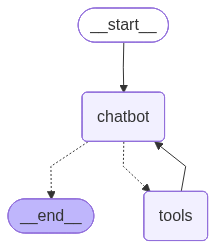

In [7]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode, tools_condition

tool_node = ToolNode(tools)

workflow = StateGraph(State)

workflow.add_node('chatbot',chatbot)
workflow.add_node('tools',tool_node)

workflow.add_edge(START,'chatbot')
workflow.add_edge('tools','chatbot')

workflow.add_conditional_edges(
    'chatbot',
    tools_condition,
    {'tools':'tools',END:END}
)

# checkpointer를 등록하면 thread_id 기준으로 checkpointer가 저장된다.
prebuilt_graph = workflow.compile(checkpointer=checkpointer)
prebuilt_graph

## Thread configuration

- checkpointer를 사용하는 그래프는 실행할 때 config를 함께 전달해야 한다.
- 가장 중요한 값은 'configurable.thread_id'이다.
- 'thread_id'는 대화방 ID 또는 사용자 세션 ID 처럼 생각할 수 있다.

In [8]:
from langchain_core.messages import HumanMessage

user1_config = {'configurable':{'thread_id':'user1'}}
user2_config = {'configurable':{'thread_id':'user2'}}

In [9]:
# user1 - 첫 번째 대화
user_input = '반갑다, 챗봇! 나는 박보검이야.'

user1_state = prebuilt_graph.invoke({
    'messages': [HumanMessage(content=user_input)]},
    user1_config
)

user1_state['messages'][-1].content

'반가워요, 박보검님! 어떻게 도와드릴까요?'

In [10]:
# user1 - 두 번째 대화
user_input = '내 이름이 뭐라고?'

user1_state = prebuilt_graph.invoke({
    'messages': [HumanMessage(content=user_input)]},
    user1_config
)

# 입력은 HumanMessage 하나만 전달했지만 user1_config의 thread_id가 동일하므로 이전 메세지 이력이 함께 복원된다.
user1_state['messages'][-1].content

'당신의 이름은 박보검이라고 말씀하셨어요. 어떻게 불러드릴까요?'

In [12]:
# user2 - 첫 번째 대화
user_input = '반갑다, 챗봇! 내 이름을 알고 있어?'

user2_state = prebuilt_graph.invoke({
    'messages': [HumanMessage(content=user_input)]},
    user2_config
)

user2_state['messages'][-1].content

'반갑습니다! 현재로서는 사용자의 이름을 알지 못해요. 이름을 알려주시면 더 친근하게 대화할 수 있답니다. 이름이 어떻게 되시나요?'

In [13]:
# user1 - 세 번째 대화
user_input = '주말에 놀러가자. 그런데 내 이름이 뭐라고 했지?'

user1_state = prebuilt_graph.invoke({
    'messages': [HumanMessage(content=user_input)]},
    user1_config
)

# 입력은 HumanMessage 하나만 전달했지만 user1_config의 thread_id가 동일하므로 이전 메세지 이력이 함께 복원된다.
user1_state['messages'][-1].content

'당신의 이름은 박보검이라고 말씀하셨어요. 주말에 놀러가는 계획도 멋지네요! 어디로 가고 싶으신가요?'

## checkpoint에 저장된 현재 state 확인

In [14]:
# 특정 thread의 현재 state 확인
snapshot = prebuilt_graph.get_state(user1_config)

snapshot.values.keys()

dict_keys(['messages'])

In [15]:
len(snapshot.values['messages'])

6

In [16]:
for message in snapshot.values['messages']:
    print(type(message).__name__, ":", message.content)

HumanMessage : 반갑다, 챗봇! 나는 박보검이야.
AIMessage : 반가워요, 박보검님! 어떻게 도와드릴까요?
HumanMessage : 내 이름이 뭐라고?
AIMessage : 당신의 이름은 박보검이라고 말씀하셨어요. 어떻게 불러드릴까요?
HumanMessage : 주말에 놀러가자. 그런데 내 이름이 뭐라고 했지?
AIMessage : 당신의 이름은 박보검이라고 말씀하셨어요. 주말에 놀러가는 계획도 멋지네요! 어디로 가고 싶으신가요?


## Checkpointer History 확인

In [17]:
history = list(prebuilt_graph.get_state_history(user1_config))

len(history)

9

In [18]:
for idx, snapshot in enumerate(history, start=1):
    message_count = len(snapshot.values.get('message',[]))
    print(f'{idx}, messages={message_count},next={snapshot.next}')

1, messages=0,next=()
2, messages=0,next=('chatbot',)
3, messages=0,next=('__start__',)
4, messages=0,next=()
5, messages=0,next=('chatbot',)
6, messages=0,next=('__start__',)
7, messages=0,next=()
8, messages=0,next=('chatbot',)
9, messages=0,next=('__start__',)
